<a href="https://colab.research.google.com/github/BrianCarela/Data-analytics-practice/blob/main/phase1_deep_dive.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🐍 Phase 1 — Deep Dive: Python for Data
## Slow, thorough, with lots of practice

---

### How to use this notebook

- **Read every explanation** before running the code. Don't skip.
- **Run every code cell** — even if you think you get it. Seeing output builds memory.
- **Do every exercise** marked with 🏋️. These are where the real learning happens.
- **Break things on purpose.** Change values, delete parts, re-run. Errors teach you more than clean code.
- Cells are meant to be run **top to bottom** in order.

### What you'll learn

0. The libraries: `pandas`, `numpy`, `matplotlib`, `seaborn` — what they are and why they exist
1. Variables & types
2. Lists
3. Loops
4. List comprehensions
5. Functions

---

# 📦 Section 0: The Four Libraries (and Why They Exist)

Python by itself is a general-purpose language. It can do math, handle text, build websites — but it doesn't *specialize* in anything. When data scientists work with Python, they rely on four core libraries that turn Python into a data powerhouse.

Think of it like a kitchen. Python is the kitchen itself. These libraries are the specialized tools:

---

### `numpy` — The Calculator
NumPy stands for **Numerical Python**. It gives Python the ability to do fast math on large collections of numbers (called **arrays**). Under the hood, almost all data science in Python runs on NumPy — even when you don't see it directly.

When you need: math, statistics, arrays of numbers → **numpy**.

---

### `pandas` — The Spreadsheet
Pandas gives you **DataFrames** — tables with rows and columns, just like Excel or a database table. It's named after *panel data*, a statistics term for structured datasets. Pandas is built on top of NumPy.

When you need: loading data, filtering rows, grouping, summarizing, cleaning → **pandas**.

---

### `matplotlib` — The Graph Paper
Matplotlib is the foundational charting library. It gives you total control over every pixel of a chart — but that also means more code. It's like drawing a chart by hand.

When you need: full control over charts, custom plots, saving figures → **matplotlib**.

---

### `seaborn` — The Chart Shortcut
Seaborn is built on top of Matplotlib. It creates beautiful statistical charts with much less code. It's designed specifically for data analysis — it understands DataFrames natively.

When you need: clean, beautiful charts fast — especially for EDA → **seaborn**.

---

**The relationship:**
```
numpy  ←  pandas  (pandas uses numpy internally)
matplotlib  ←  seaborn  (seaborn uses matplotlib internally)
```

You rarely need to choose between them — you use all four together.

In [ ]:
# We import libraries using the 'import' keyword.
# 'as pd' means: give it a short nickname so we don't type 'pandas' every time.
# This is a universal convention — everyone uses these same abbreviations.

import numpy as np          # nickname: np
import pandas as pd         # nickname: pd
import matplotlib.pyplot as plt   # nickname: plt (we import the 'pyplot' submodule specifically)
import seaborn as sns       # nickname: sns

# This line makes charts appear inline (inside the notebook, not in a separate window)
%matplotlib inline

print('All four libraries loaded successfully!')
print(f'numpy version:      {np.__version__}')
print(f'pandas version:     {pd.__version__}')

All four libraries loaded successfully!
numpy version:      2.0.2
pandas version:     2.2.2


## 🎨 What Can These Libraries Actually Do?

Before we learn the fundamentals, let's see some cool charts so you know what you're working toward. We'll use the classic **Tips dataset** (restaurant tip data) that comes built into seaborn.

Don't worry about understanding every line yet — just **run the cells and look at the output**. By the end of Phase 2, you'll be writing these yourself.

In [ ]:
# Seaborn has several built-in datasets for practice
# load_dataset() downloads it automatically — no file needed
tips = sns.load_dataset('tips')

print(f'Rows: {tips.shape[0]}, Columns: {tips.shape[1]}')
tips.head(10)  # Show first 10 rows

Rows: 244, Columns: 7


,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
5,25.29,4.71,Male,No,Sun,Dinner,4
6,8.77,2.00,Male,No,Sun,Dinner,2
7,26.88,3.12,Male,No,Sun,Dinner,4
8,15.04,1.96,Male,No,Sun,Dinner,2
9,14.78,3.23,Male,No,Sun,Dinner,2


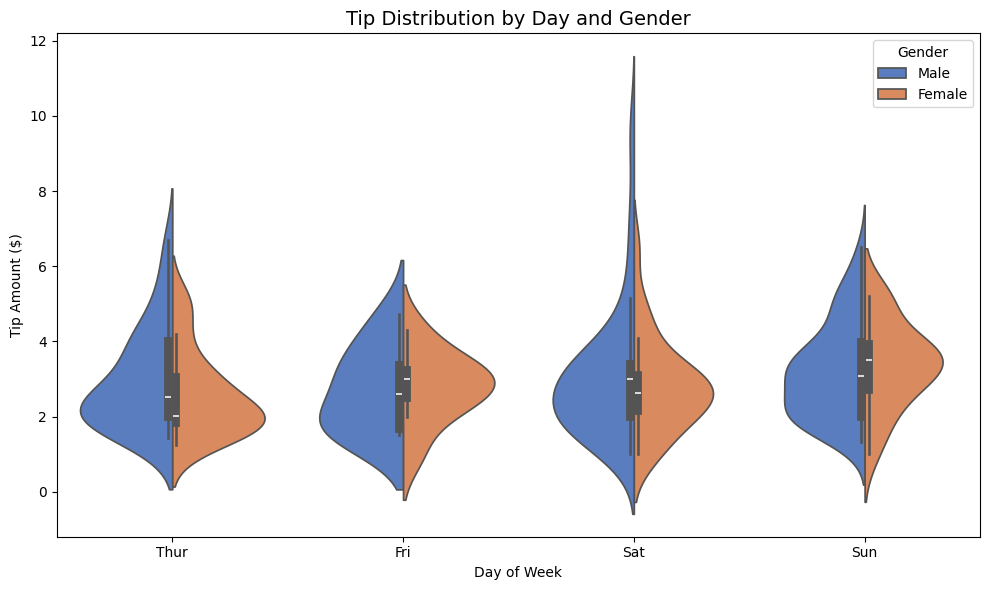

Insight: The shape shows WHERE most tips cluster, not just the average.


In [ ]:
# CHART 1: Violin Plot
# Shows the full distribution of tip amounts by day AND gender at once
# The wider the violin, the more data points exist at that value

plt.figure(figsize=(10, 6))
sns.violinplot(data=tips, x='day', y='tip', hue='sex', split=True, palette='muted')
plt.title('Tip Distribution by Day and Gender', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Tip Amount ($)')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()
print('Insight: The shape shows WHERE most tips cluster, not just the average.')

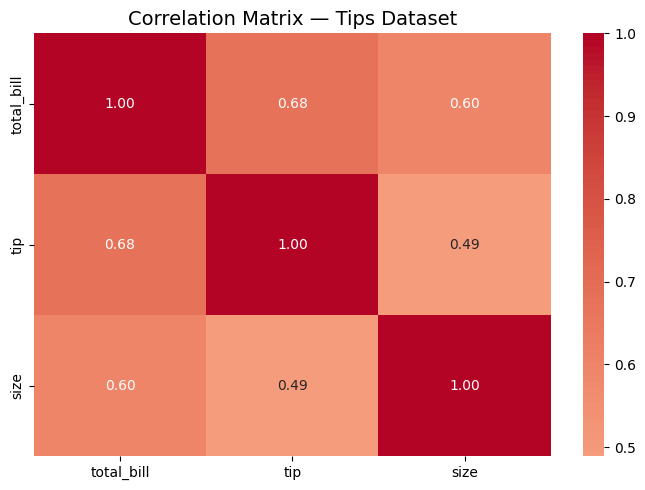

Insight: total_bill and tip have a 0.68 correlation — strong positive relationship.


In [ ]:
# CHART 2: Correlation Heatmap
# This is the chart at the end of your old notebook!
# It shows how strongly each numeric variable is related to every other.
# 1.0 = perfect positive relationship, -1.0 = perfect negative, 0 = no relationship

plt.figure(figsize=(7, 5))
numeric_tips = tips.select_dtypes(include='number')  # only numeric columns
sns.heatmap(numeric_tips.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix — Tips Dataset', fontsize=14)
plt.tight_layout()
plt.show()
print('Insight: total_bill and tip have a 0.68 correlation — strong positive relationship.')

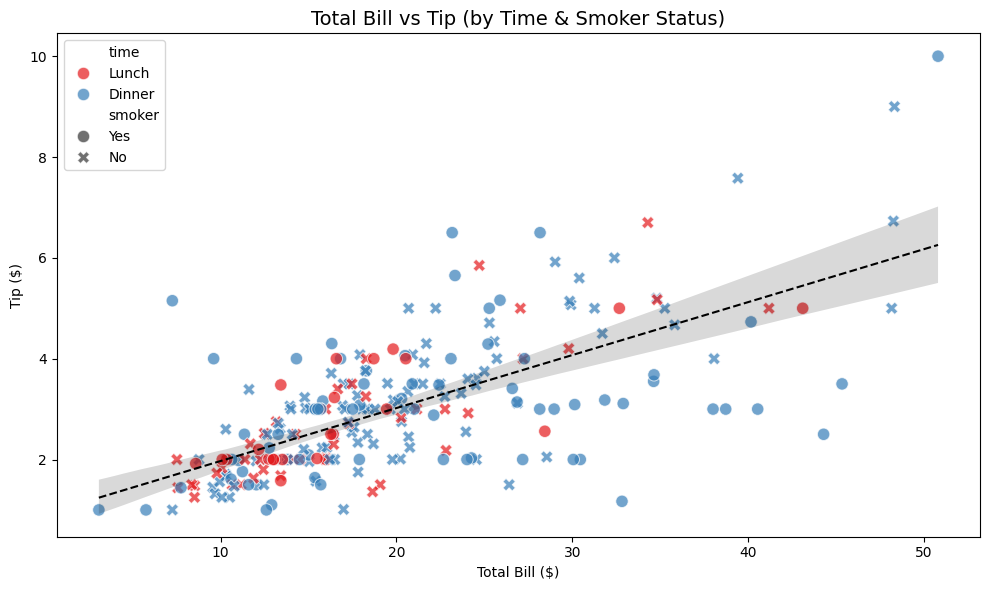

Insight: Bigger bills generally mean bigger tips, but with high variance.


In [ ]:
# CHART 3: Scatter plot with regression line
# Shows the relationship between total bill and tip,
# colored by time of day, with a best-fit line

plt.figure(figsize=(10, 6))
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', style='smoker',
                alpha=0.7, s=80, palette='Set1')
# Add a regression line (trend line)
sns.regplot(data=tips, x='total_bill', y='tip', scatter=False,
            color='black', line_kws={'linestyle': '--', 'linewidth': 1.5})
plt.title('Total Bill vs Tip (by Time & Smoker Status)', fontsize=14)
plt.xlabel('Total Bill ($)')
plt.ylabel('Tip ($)')
plt.tight_layout()
plt.show()
print('Insight: Bigger bills generally mean bigger tips, but with high variance.')

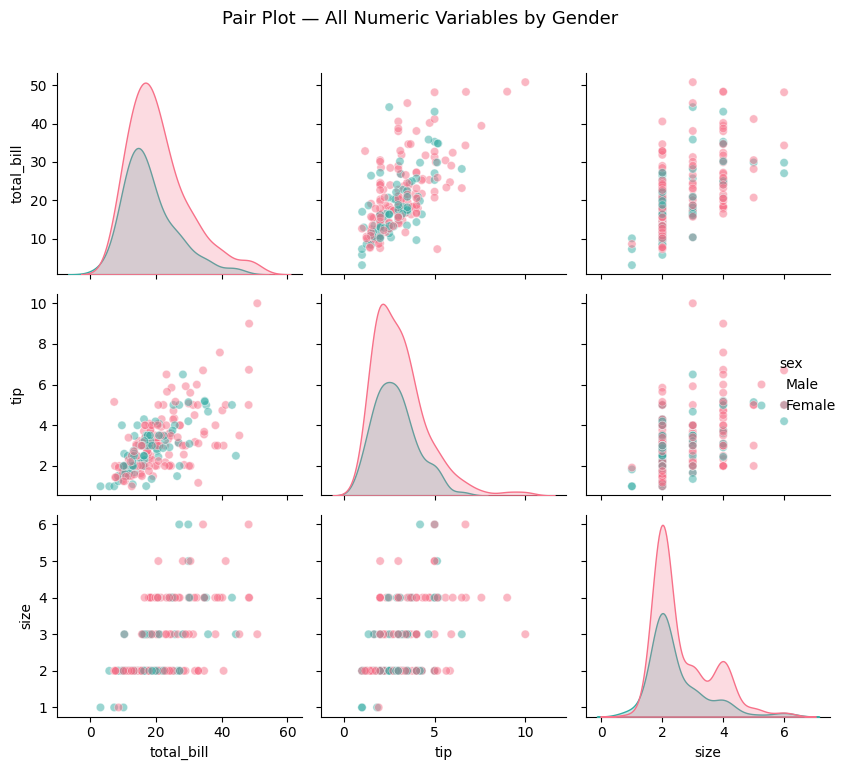

This one chart replaces about 6 individual charts.


In [ ]:
# CHART 4: Pair Plot — The EDA power move
# Automatically plots every numeric variable against every other.
# The diagonal shows the distribution of each variable.
# This is often the FIRST chart analysts make with a new dataset.

sns.pairplot(tips, hue='sex', plot_kws={'alpha': 0.5}, palette='husl')
plt.suptitle('Pair Plot — All Numeric Variables by Gender', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()
print('This one chart replaces about 6 individual charts.')

**That's what you're learning toward.** Now let's build the foundation.

---

# 🐍 Section 1: Variables & Types

## What is a variable?

A variable is a **named container** that holds a value. You create one by writing a name, an equals sign, and the value. Python figures out the type automatically — you don't have to declare it.

```python
# JavaScript              # Python
let name = "Pidjin";     # name = "Pidjin"
const age = 30;          # age = 30
let isActive = true;     # is_active = True
```

Key differences from JavaScript:
- No `let`, `const`, or `var` — just assign directly
- Python uses `snake_case` by convention (underscores), not camelCase
- Booleans are capitalized: `True` and `False` (not `true`/`false`)

## The main types you'll use in data work:

| Type | Example | What it is |
|------|---------|------------|
| `int` | `42` | Whole number |
| `float` | `3.14` | Decimal number |
| `str` | `"hello"` | Text (string) |
| `bool` | `True` | True or False |
| `None` | `None` | No value (like `null` in JS) |

In [ ]:
# === CREATING VARIABLES ===

patient_name = "Maria"        # str: text, always in quotes
patient_age = 34              # int: whole number, no quotes
patient_bmi = 27.4            # float: decimal number
is_smoker = False             # bool: True or False (capital T/F!)
last_checkup = None           # None: represents 'no value'

# type() tells you what type a variable is
print(type(patient_name))     # <class 'str'>
print(type(patient_age))      # <class 'int'>
print(type(patient_bmi))      # <class 'float'>
print(type(is_smoker))        # <class 'bool'>
print(type(last_checkup))     # <class 'NoneType'>

<class 'str'>
<class 'int'>
<class 'float'>
<class 'bool'>
<class 'NoneType'>


In [ ]:
# === F-STRINGS: Building readable output ===
# An f-string lets you embed variables directly inside a string.
# Prefix the string with f, then use {variable_name} inside.

# Without f-string (ugly, hard to read):
print("Patient: " + patient_name + ", Age: " + str(patient_age))

# With f-string (clean):
print(f"Patient: {patient_name}, Age: {patient_age}")

# You can do math and formatting INSIDE the curly braces:
annual_premium = 12345.678
print(f"Annual premium: ${annual_premium:.2f}")    # :.2f = 2 decimal places
print(f"Annual premium: ${annual_premium:,.0f}")   # :, = comma separator, .0f = no decimals
print(f"BMI category: {'Overweight' if patient_bmi >= 25 else 'Normal'}")  # even if/else!

Patient: Maria, Age: 34
Patient: Maria, Age: 34
Annual premium: $12345.68
Annual premium: $12,346
BMI category: Overweight


In [ ]:
# === TYPE CONVERSION ===
# Sometimes data comes in the wrong type and you need to convert it.
# This happens constantly when loading real-world data.

age_as_string = "45"       # Imagine this came from a CSV file
print(type(age_as_string)) # It's a str — you can't do math on it yet!

# Convert str → int
age_as_int = int(age_as_string)
print(f"After conversion: {age_as_int + 5}")  # Now math works

# Convert int → float
age_as_float = float(age_as_int)
print(f"As float: {age_as_float}")

# Convert number → string
bmi_label = "BMI: " + str(patient_bmi)
print(bmi_label)

<class 'str'>
After conversion: 50
As float: 45.0
BMI: 27.4


## 🏋️ Exercise 1a — Create Your Own Variables

Create variables to describe a fictional insurance customer:
- Their name (string)
- Their age (int)
- Their yearly income (float)
- Whether they have dependents (bool)
- Their number of past claims — start it as `None`

Then print a summary sentence using an f-string that looks like:

`"[Name], age [age], earns $[income] per year. Has dependents: [True/False]"`

Format the income with commas and no decimals.

In [ ]:
# Your code here
Name = "Aly"
age = 28
income = 33000
dependents = False
past_claims = None

print(f'{Name}, age {age}, earns ${income:,.0f} per year. Has dependents: {dependents}')

Aly, age 28, earns $33,000 per year. Has dependents: False


## 🏋️ Exercise 1b — Type Conversion Practice

The following variables were loaded from a CSV file and came in as strings. Convert them to the correct types and then do something useful with them:

1. Convert `charge_str` to a float, then calculate what 20% of it is
2. Convert `children_str` to an int, then print whether they have more than 2 children
3. Convert `is_smoker_str` to a proper boolean (hint: use `== 'yes'`)

In [ ]:
# These came in as strings from a CSV file
charge_str = "14234.56"
children_str = "3"
is_smoker_str = "yes"

# Your code here
charge_float = float(charge_str)
print(f'20% of the charge is {(charge_float * .2):.2f}')

children_int = int(children_str)
print(f'Has more than 2 children: {children_int > 2}')

is_smoker_bool = is_smoker_str.lower() == 'yes' # .lower() used to capture any capital letters
print(f'Is a smoker: {is_smoker_bool}')

20% of the charge is 2846.91
Has more than 2 children: True
Is a smoker: True


---
# 📋 Section 2: Lists

## What is a list?

A list is an **ordered collection of items**, stored in a single variable. In JavaScript, this is called an **array** — same concept, slightly different syntax.

```python
# JavaScript             # Python
let nums = [1, 2, 3];   # nums = [1, 2, 3]
nums[0]                  # nums[0]    ← same!
nums.length              # len(nums)  ← different
nums.push(4)             # nums.append(4)  ← different
```

Lists can hold **any type of data**, and you can mix types (though you usually won't).

## Indexing — how to access items

Every item in a list has an **index** (position number), starting at 0.

```
list:   ['a', 'b', 'c', 'd']
index:    0    1    2    3
neg:     -4   -3   -2   -1   ← negative indexes count from the end
```

Python's negative indexing is a superpower — `list[-1]` always gets the last item, regardless of length.

In [ ]:
# === CREATING LISTS ===

charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50, 875.00, 14500.00]
regions = ['northeast', 'northwest', 'southeast', 'southwest']
mixed   = ["Maria", 34, 27.4, False, None]  # you CAN mix types

print(f"charges list: {charges}")
print(f"Number of items: {len(charges)}")  # len() gives the count

# Accessing items by index
print(f"\nFirst charge (index 0):  {charges[0]}")
print(f"Third charge (index 2):  {charges[2]}")
print(f"Last charge (index -1):  {charges[-1]}")
print(f"Second to last (-2):     {charges[-2]}")

charges list: [1250.0, 8340.2, 450.75, 22000.99, 3200.5, 875.0, 14500.0]
Number of items: 7

First charge (index 0):  1250.0
Third charge (index 2):  450.75
Last charge (index -1):  14500.0
Second to last (-2):     875.0


In [ ]:
# === SLICING: Getting a portion of a list ===
# Syntax: list[start:stop]  — includes start, EXCLUDES stop
# Think of it as: 'from position start, up to (but not including) stop'

charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50, 875.00, 14500.00]

print(f"First 3:       {charges[0:3]}")   # items at index 0, 1, 2
print(f"Items 2-4:     {charges[2:5]}")   # items at index 2, 3, 4
print(f"Last 3:        {charges[-3:]}")   # from 3rd-to-last onward
print(f"All but last:  {charges[:-1]}")   # everything except the last
print(f"Every other:   {charges[::2]}")   # step of 2
print(f"Reversed:      {charges[::-1]}")  # step of -1 = reverse!

First 3:       [1250.0, 8340.2, 450.75]
Items 2-4:     [450.75, 22000.99, 3200.5]
Last 3:        [3200.5, 875.0, 14500.0]
All but last:  [1250.0, 8340.2, 450.75, 22000.99, 3200.5, 875.0]
Every other:   [1250.0, 450.75, 3200.5, 14500.0]
Reversed:      [14500.0, 875.0, 3200.5, 22000.99, 450.75, 8340.2, 1250.0]


In [ ]:
# === MODIFYING LISTS ===

charges = [1250.00, 8340.20, 450.75]

# append() adds one item to the END
charges.append(5500.00)
print(f"After append:  {charges}")

# insert() adds at a specific position
charges.insert(1, 999.00)   # insert 999.00 at index 1
print(f"After insert:  {charges}")

# remove() removes the first occurrence of a value
charges.remove(999.00)
print(f"After remove:  {charges}")

# pop() removes AND RETURNS the last item (or by index)
last = charges.pop()
print(f"Popped:        {last}")
print(f"After pop:     {charges}")

# Change a value at a specific index
charges[0] = 1300.00
print(f"After change:  {charges}")

After append:  [1250.0, 8340.2, 450.75, 5500.0]
After insert:  [1250.0, 999.0, 8340.2, 450.75, 5500.0]
After remove:  [1250.0, 8340.2, 450.75, 5500.0]
Popped:        5500.0
After pop:     [1250.0, 8340.2, 450.75]
After change:  [1300.0, 8340.2, 450.75]


In [ ]:
# === USEFUL LIST OPERATIONS ===

charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50]

print(f"Sum:     ${sum(charges):,.2f}")
print(f"Min:     ${min(charges):,.2f}")
print(f"Max:     ${max(charges):,.2f}")
print(f"Average: ${sum(charges)/len(charges):,.2f}")

# sorted() returns a NEW sorted list without changing the original
sorted_asc  = sorted(charges)
sorted_desc = sorted(charges, reverse=True)
print(f"\nAscending:  {sorted_asc}")
print(f"Descending: {sorted_desc}")
print(f"Original unchanged: {charges}")

# Check if an item is IN a list
print(f"\nIs 8340.20 in list? {8340.20 in charges}")
print(f"Is 9999.00 in list? {9999.00 in charges}")

## 🏋️ Exercise 2a — List Operations

Start with this list of ages: `[23, 45, 31, 58, 27, 62, 39, 44, 51, 29]`

1. Print the youngest and oldest age
2. Print the average age (round to 1 decimal place)
3. Print the ages in descending order
4. Print only the first 4 ages from the sorted list
5. Check if age 58 is in the list — print a sentence: `"Age 58 is in the list: True"`

In [ ]:
ages = [23, 45, 31, 58, 27, 62, 39, 44, 51, 29]

# Your code here
#1
ages_young_to_old = sorted(ages)
print("oldest age: ")
print(ages_young_to_old[-1])
print("youngest age:")
print(ages_young_to_old[0])

# more efficient solution
print(f"Youngest: {min(ages)}, Oldest: {max(ages)}")

#2
avg_age = sum(ages)/len(ages)
print(f"avg age: \n{avg_age:,.1f}")

#3
print(f"ages in descending order: \n{sorted(ages, reverse=True)}")

#4
print(f"first 4 ages from sorted list: \n{sorted(ages)[0:4]}")

#5
print(f"Age 58 is in the list: {58 in ages}")


oldest age: 
62
youngest age:
23
avg age: 
40.9
ages in descending order: 
[62, 58, 51, 45, 44, 39, 31, 29, 27, 23]
first 4 ages: 
[23, 45, 31, 58]
Age 58 is in the list: True


## 🏋️ Exercise 2b — Build a List from Scratch

1. Start with an empty list called `high_risk_ages`
2. From the ages list above, manually `.append()` every age that is over 50
3. Print the resulting list
4. Print how many high-risk ages there are
5. Add age 70 to the end of the list
6. Remove the first item from the list using `.pop(0)` and save it in a variable — print what was removed

In [ ]:
ages = [23, 45, 31, 58, 27, 62, 39, 44, 51, 29]
#1
high_risk_ages = []

# Your code here
#2
for age in ages:
  if age > 50:
    high_risk_ages.append(age)

# more efficient method:
# "Give me each age, for each age in ages, but only if that age is over 50."
# high_risk_ages = [age for age in ages if age > 50]

#3
print(f"high_risk_ages: {high_risk_ages}")

#4
print(f"number of high-risk ages: {len(high_risk_ages)}")

#5
high_risk_ages.append(70)

#6
first_high_risk_age = high_risk_ages.pop(0)
print(f"first high risk age removed: {first_high_risk_age}")

high_risk_ages: [58, 62, 51]
number of high-risk ages: 3
first high risk age removed: 58


---
# 🔁 Section 3: Loops

## What is a loop?

A loop runs the same block of code **multiple times** — once for each item in a collection, or until a condition is met.

In data work, loops let you process many rows, check many conditions, and build new collections automatically.

## Python has two types of loops:

### `for` loop — "do this FOR each item in a collection"
```python
for item in collection:
    # do something with item
```

### `while` loop — "keep doing this WHILE a condition is true"
```python
while condition:
    # do something
    # must eventually make condition False or you loop forever!
```

In data analysis, you'll use `for` loops **much** more often. `while` loops are more common in app development.

### ⚠️ Indentation is not optional
Python uses **indentation** (spaces or tabs) to define what's inside the loop. This replaces the curly braces `{}` from JavaScript.

```python
# CORRECT
for x in nums:
    print(x)     # ← 4 spaces indent = inside the loop

# BROKEN — Python will throw an IndentationError
for x in nums:
print(x)         # ← no indent = Python doesn't know this is in the loop
```

In [ ]:
# === BASIC FOR LOOP ===

regions = ['northeast', 'northwest', 'southeast', 'southwest']

# Read as: "for each region in the regions list..."
for region in regions:
    print(f"Region: {region.upper()}")

print('--- loop finished ---')

In [ ]:
# === RANGE: Looping a specific number of times ===
# range(n) generates numbers from 0 up to (but not including) n
# range(start, stop) — from start to stop (exclusive)
# range(start, stop, step) — with a step size

print('range(5):')
for i in range(5):
    print(f'  i = {i}')

print('\nrange(2, 8):')
for i in range(2, 8):
    print(f'  i = {i}')

print('\nrange(0, 20, 5):')  # every 5th number
for i in range(0, 20, 5):
    print(f'  i = {i}')

In [ ]:
# === ENUMERATE: When you need the index AND the value ===
# enumerate() gives you both: (index, value) pairs

charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50]

for i, charge in enumerate(charges):
    print(f"Patient #{i+1}: ${charge:,.2f}")  # i+1 so we start at 1 not 0

In [ ]:
# === IF/ELSE INSIDE A LOOP ===
# This is where things get powerful — conditional logic per item

charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50, 875.00]
threshold = 5000

for charge in charges:
    if charge > threshold:
        label = '⚠️  HIGH'
    elif charge > 2000:
        label = '📊 MEDIUM'
    else:
        label = '✅ LOW'
    print(f"${charge:>9,.2f}  →  {label}")

$ 1,250.00  →  ✅ LOW
$ 8,340.20  →  ⚠️  HIGH
$   450.75  →  ✅ LOW
$22,000.99  →  ⚠️  HIGH
$ 3,200.50  →  📊 MEDIUM
$   875.00  →  ✅ LOW


In [ ]:
# === ACCUMULATING RESULTS IN A LOOP ===
# A very common pattern: start with an empty container,
# add to it on each loop iteration

charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50, 875.00]

# Collect all high charges into a new list
high_charges = []
total_high = 0

for charge in charges:
    if charge > 5000:
        high_charges.append(charge)
        total_high += charge   # same as: total_high = total_high + charge

print(f"High charges: {high_charges}")
print(f"Number of high charges: {len(high_charges)}")
print(f"Total of high charges: ${total_high:,.2f}")

In [ ]:
# === ZIP: Looping over TWO lists at the same time ===
# zip() pairs up items from two lists by position

names   = ['Alice', 'Bob', 'Carol', 'David']
charges = [12340.00, 3200.50, 875.00, 18900.75]

for name, charge in zip(names, charges):
    print(f"{name:<8} owes ${charge:>10,.2f}")

## 🏋️ Exercise 3a — Loop with Conditional Logic

Given the BMI list below:
1. Loop through each BMI value
2. For each one, classify it as: `Underweight` (<18.5), `Normal` (18.5–24.9), `Overweight` (25–29.9), or `Obese` (30+)
3. Print each BMI with its classification
4. Count how many are in each category and print the totals at the end

In [ ]:
bmis = [17.2, 22.1, 28.4, 31.7, 24.9, 16.8, 33.2, 26.0, 19.5, 30.1]

# Your code here
underweight = []
normal = []
overweight = []
obese = []

# 1
for bmi in bmis:
  # 2
  if bmi < 18.5:
    label = 'Underweight'
    underweight.append(bmi)
  elif bmi < 25:
    label = 'Normal'
    normal.append(bmi)
  elif bmi < 30:
    label = 'Overweight'
    overweight.append(bmi)
  else:
    label = 'Obese'
    obese.append(bmi)
  # 3
  print(f"bmi {bmi} is {label}")

# 4
print("\n")
print(f"total underweight bmi: {len(underweight)}")
print(f"total normal bmi: {len(normal)}")
print(f"total overweight bmi: {len(overweight)}")
print(f"total obese bmi: {len(obese)}")

# cleaner solution using dictionary
# counts = {'Underweight': 0, 'Normal': 0, 'Overweight': 0, 'Obese': 0}

# for bmi in bmis:
#     if bmi < 18.5:
#         label = 'Underweight'
#     elif bmi < 25:
#         label = 'Normal'
#     elif bmi < 30:
#         label = 'Overweight'
#     else:
#         label = 'Obese'
#     print(f"bmi {bmi} is {label}")
#     counts[label] += 1

# for category, total in counts.items():
#     print(f"total {category.lower()} bmi: {total}")


bmi 17.2 is Underweight
bmi 22.1 is Normal
bmi 28.4 is Overweight
bmi 31.7 is Obese
bmi 24.9 is Normal
bmi 16.8 is Underweight
bmi 33.2 is Obese
bmi 26.0 is Overweight
bmi 19.5 is Normal
bmi 30.1 is Obese


total underweight bmi: 2
total normal bmi: 3
total overweight bmi: 2
total obese bmi: 3


## 🏋️ Exercise 3b — Accumulator Pattern

You have two parallel lists — one of patient names, one of their charges.
Using a loop with `zip()`:
1. Build a new list called `expensive_patients` that contains only the names of patients whose charges exceed $10,000
2. Calculate the total amount owed by expensive patients only
3. Print a summary at the end

In [ ]:
names   = ['Alice', 'Bob', 'Carol', 'David', 'Eve', 'Frank']
charges = [12340.00, 3200.50, 875.00, 18900.75, 10500.00, 4200.30]

expensive_patients = []
expensive_charges = []

# Your code here
# 1
for name, charge in zip(names, charges):
  # 2
  if charge > 10000:
    expensive_patients.append(name)
    expensive_charges.append(charge)

# 3
print(f"expensive patients: {expensive_patients} \ntotal charges: ${sum(expensive_charges):,.2f}")


expensive patients: ['Alice', 'David', 'Eve'] 
total charges: $41,740.75


## 🏋️ Exercise 3c — The Classic FizzBuzz (Data Variant)

Loop through numbers 1 to 20. For each number:
- If divisible by 3 AND 5 → print `"High Risk Smoker"`
- If divisible by 3 only → print `"Smoker"`
- If divisible by 5 only → print `"Obese"`
- Otherwise → print the number itself

Hint: use the modulo operator `%` to check divisibility. `10 % 5 == 0` means 10 is divisible by 5.

In [ ]:
# Your code here
for count in range(1, 21):
  if count % 5 == 0 and count % 3 == 0:
    print("High Risk Smoker")
  elif count % 3 == 0:
    print("Smoker")
  elif count % 5 == 0:
    print("Obese")
  else:
    print(count)
  count += 1

1
2
Smoker
4
Obese
Smoker
7
8
Smoker
Obese
11
Smoker
13
14
High Risk Smoker
16
17
Smoker
19
Obese


---
# ⚡ Section 4: List Comprehensions

## What is a list comprehension?

A list comprehension is a **compact, one-line way to build a list**. It replaces the common pattern of:
1. Create an empty list
2. Loop through something
3. Append items to the list

```python
# The long way (loop + accumulate):
doubled = []
for x in numbers:
    doubled.append(x * 2)

# The list comprehension way (same result, one line):
doubled = [x * 2 for x in numbers]
```

## Syntax

```python
[expression  for  item  in  iterable  if  condition]
#  ↑ what       ↑ variable  ↑ source    ↑ optional filter
# to produce     name       to loop
#                           through
```

Read it left to right: **"Give me [expression] for each [item] in [iterable] where [condition]"**

The `if condition` part is optional — you only include it when you want to filter.

In [ ]:
# === BASIC LIST COMPREHENSION ===

charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50]

# Apply a 10% increase to all charges
# Long way:
increased_long = []
for c in charges:
    increased_long.append(c * 1.10)

# List comprehension:
increased_comp = [c * 1.10 for c in charges]

print('Long way:   ', increased_long)
print('Comprehension:', increased_comp)
print('Same result?', increased_long == increased_comp)

Long way:    [1375.0, 9174.220000000001, 495.82500000000005, 24201.089000000004, 3520.55]
Comprehension: [1375.0, 9174.220000000001, 495.82500000000005, 24201.089000000004, 3520.55]
Same result? True


In [ ]:
# === LIST COMPREHENSION WITH FILTERING ===
# Adding 'if condition' at the end filters which items get included

charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50, 875.00, 14500.00]

# Only charges over $5000
high = [c for c in charges if c > 5000]
print(f"High charges (>$5000): {high}")

# Only charges between $1000 and $10000
medium = [c for c in charges if 1000 <= c <= 10000]
print(f"Medium charges ($1k-$10k): {medium}")

# Round all charges to nearest dollar
rounded = [round(c) for c in charges]
print(f"Rounded: {rounded}")

High charges (>$5000): [8340.2, 22000.99, 14500.0]
Medium charges ($1k-$10k): [1250.0, 8340.2, 3200.5]
Rounded: [1250, 8340, 451, 22001, 3200, 875, 14500]


In [ ]:
# === LIST COMPREHENSION WITH TRANSFORMATION ===
# You can apply any expression or function call

names = ['alice johnson', 'bob smith', 'carol white', 'david brown']

# Capitalize all names
capitalized = [name.title() for name in names]
print(f"Capitalized: {capitalized}")

# Get just first names
first_names = [name.split()[0] for name in names]  # split() splits on spaces
print(f"First names: {first_names}")

# Get lengths of each name
lengths = [len(name) for name in names]
print(f"Name lengths: {lengths}")

Capitalized: ['Alice Johnson', 'Bob Smith', 'Carol White', 'David Brown']
First names: ['alice', 'bob', 'carol', 'david']
Name lengths: [13, 9, 11, 11]


In [ ]:
# === INLINE IF/ELSE IN A COMPREHENSION ===
# When you want to transform items differently based on a condition
# Syntax: [value_if_true if condition else value_if_false  for item in list]

charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50]

labels = ['HIGH' if c > 5000 else 'LOW' for c in charges]
print(f"Labels: {labels}")

# Combine: build a list of formatted strings
summaries = [f"${c:,.0f} ({('HIGH' if c > 5000 else 'LOW')})" for c in charges]
for s in summaries:
    print(f"  {s}")

Labels: ['LOW', 'HIGH', 'LOW', 'HIGH', 'LOW']
  $1,250 (LOW)
  $8,340 (HIGH)
  $451 (LOW)
  $22,001 (HIGH)
  $3,200 (LOW)


## 🏋️ Exercise 4a — Basic Comprehensions

Using list comprehensions (one line each):

1. From `charges`, create a list of charges that are under $3,000 — call it `low_charges`
2. From `charges`, create a list where every charge is doubled
3. From `ages`, create a list of ages that are between 30 and 60 (inclusive)
4. From `regions`, create a list with each region name in ALL CAPS

In [ ]:
charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50, 875.00, 14500.00]
ages    = [23, 45, 31, 58, 27, 62, 39, 44, 51, 29]
regions = ['northeast', 'northwest', 'southeast', 'southwest']

# 1.
low_charges = [c for c in charges if c < 3000]
print(f"Low charges: {low_charges}")

# 2.
doubled = [c * 2 for c in charges]
print(f"Doubled: {doubled}")

# 3.
middle_ages = [a for a in ages if 30 <= a <= 60]
print(f"Middle ages: {middle_ages}")

# 4.
upper_regions = [r.upper() for r in regions]
print(f"Upper regions: {upper_regions}")

Low charges: [1250.0, 450.75, 875.0]
Doubled: [2500.0, 16680.4, 901.5, 44001.98, 6401.0, 1750.0, 29000.0]
Middle ages: [45, 31, 58, 39, 44, 51]
Upper regions: ['NORTHEAST', 'NORTHWEST', 'SOUTHEAST', 'SOUTHWEST']


## 🏋️ Exercise 4b — Comprehension as Data Transformation

You have a list of BMI values. Using list comprehensions:

1. Create a list of BMI *categories* (as strings) for each BMI — use the same 4 categories from before
2. Create a list of booleans: `True` if BMI is "at risk" (>= 25), `False` otherwise
3. Count how many are at risk (hint: `sum()` on a boolean list counts the `True` values)

In [ ]:
bmis = [17.2, 22.1, 28.4, 31.7, 24.9, 16.8, 33.2, 26.0, 19.5, 30.1]

# 1. Categories — use nested if/else inside the comprehension
categories = ['underweight' if b < 18.5 else 'normal' if b < 25 else 'overweight' if b < 30 else 'obese' for b in bmis]# your code here
print(f"Categories: {categories}")

# 2. At-risk booleans
at_risk = [b >= 25 for b in bmis] # your code here
print(f"At risk: {at_risk}")

# 3. Count
count_at_risk = sum(at_risk) # your code here
print(f"Number at risk: {count_at_risk} out of {len(bmis)}")

Categories: ['underweight', 'normal', 'overweight', 'obese', 'normal', 'underweight', 'obese', 'overweight', 'normal', 'obese']
At risk: [False, False, True, True, False, False, True, True, False, True]
Number at risk: 5 out of 10


---
# 🔧 Section 5: Functions

## What is a function?

A function is a **named, reusable block of code** that takes inputs, does something, and (optionally) returns an output.

You've been using functions this whole time — `len()`, `print()`, `sum()`, `sorted()` are all built-in functions. Now you'll write your own.

```python
# JavaScript             # Python
function greet(name) {   def greet(name):
    return "Hi " + name;     return "Hi " + name
}                        
```

## Anatomy of a function

```python
def function_name(parameter1, parameter2):
    """Docstring — describes what the function does."""
    # body: indented code that runs when the function is called
    result = parameter1 + parameter2
    return result          # sends the value back to the caller
```

Key terms:
- **`def`** — keyword that starts a function definition
- **Parameters** — variables the function accepts as input (in the `()`)
- **Docstring** — optional description in triple quotes (best practice)
- **`return`** — sends a value back. Without it, the function returns `None`.
- **Arguments** — the actual values you pass when CALLING the function

## Why use functions?

1. **DRY** — Don't Repeat Yourself. Write the logic once, use it anywhere.
2. **Readability** — `calculate_premium(age, bmi, smoker)` is clearer than 5 lines of math.
3. **Testability** — You can test one function in isolation.
4. **In pandas**, functions are used with `.apply()` to run on every row of a DataFrame.

In [ ]:
# === BASIC FUNCTION ===

def greet_patient(name):
    """Returns a greeting string for a patient."""
    return f"Welcome, {name}. Please have a seat."

# Call the function by name, passing arguments in parentheses
message = greet_patient("Maria")
print(message)

# Call it again with a different argument
print(greet_patient("Bob"))

Welcome, Maria. Please have a seat.
Welcome, Bob. Please have a seat.


In [ ]:
# === MULTIPLE PARAMETERS ===

def calculate_bmi(weight_kg, height_m):
    """Calculate BMI from weight (kg) and height (meters)."""
    bmi = weight_kg / (height_m ** 2)   # ** is 'to the power of'
    return round(bmi, 1)

bmi = calculate_bmi(75, 1.75)
print(f"BMI: {bmi}")

# You can also pass arguments by NAME (keyword arguments)
# Order doesn't matter when you name them
bmi2 = calculate_bmi(height_m=1.65, weight_kg=68)
print(f"BMI2: {bmi2}")

BMI: 24.5
BMI2: 25.0


In [ ]:
# === DEFAULT PARAMETER VALUES ===
# You can give parameters a default value — if the caller doesn't
# provide that argument, the default is used.

def calculate_premium(base_charge, tax_rate=0.08, discount=0.0):
    """Calculate final premium with optional tax and discount."""
    after_discount = base_charge * (1 - discount)
    final = after_discount * (1 + tax_rate)
    return round(final, 2)

# Using all defaults
print(f"Default: ${calculate_premium(1000)}")                 # tax=0.08, no discount

# Override tax rate only
print(f"Custom tax: ${calculate_premium(1000, tax_rate=0.12)}")

# Override both
print(f"Custom both: ${calculate_premium(1000, tax_rate=0.12, discount=0.10)}")

Default: $1080.0
Custom tax: $1120.0
Custom both: $1008.0


In [ ]:
# === RETURNING MULTIPLE VALUES ===
# Python functions can return more than one value using a tuple

def analyze_charges(charge_list):
    """Return mean, median, and standard deviation of a list of charges."""
    mean   = sum(charge_list) / len(charge_list)
    sorted_list = sorted(charge_list)
    n = len(sorted_list)
    # Median calculation
    if n % 2 == 0:
        median = (sorted_list[n//2 - 1] + sorted_list[n//2]) / 2
    else:
        median = sorted_list[n//2]
    # Standard deviation (manual)
    variance = sum((x - mean) ** 2 for x in charge_list) / n
    std_dev = variance ** 0.5
    return round(mean, 2), round(median, 2), round(std_dev, 2)

charges = [1250.00, 8340.20, 450.75, 22000.99, 3200.50, 875.00]

# Unpack the three returned values into three variables
mean, median, std = analyze_charges(charges)

print(f"Mean:    ${mean:,.2f}")
print(f"Median:  ${median:,.2f}")
print(f"Std Dev: ${std:,.2f}")
print(f"\nNote: mean (${mean:,.0f}) > median (${median:,.0f}) — distribution is right-skewed")

Mean:    $6,019.57
Median:  $2,225.25
Std Dev: $7,626.33

Note: mean ($6,020) > median ($2,225) — distribution is right-skewed


In [ ]:
# === FUNCTIONS + LIST COMPREHENSIONS ===
# This is the pattern you'll use constantly in pandas with .apply()

def classify_bmi(bmi):
    """Return BMI category string."""
    if bmi < 18.5:
        return 'Underweight'
    elif bmi < 25:
        return 'Normal'
    elif bmi < 30:
        return 'Overweight'
    else:
        return 'Obese'

def classify_age(age):
    """Return age group string."""
    if age < 30:
        return 'Young'
    elif age < 60:
        return 'Middle-aged'
    else:
        return 'Senior'

bmis = [17.2, 22.1, 28.4, 31.7, 24.9]
ages = [23, 45, 31, 58, 62]

# Apply the function to every item in the list — one line!
bmi_categories = [classify_bmi(b) for b in bmis]
age_groups     = [classify_age(a) for a in ages]

print('BMI categories:', bmi_categories)
print('Age groups:    ', age_groups)

BMI categories: ['Underweight', 'Normal', 'Overweight', 'Obese', 'Normal']
Age groups:     ['Young', 'Middle-aged', 'Middle-aged', 'Middle-aged', 'Senior']


## 🏋️ Exercise 5a — Write Your Own Functions

Write the following functions:

**1. `classify_charge(charge)`** — Returns:
- `'Low'` if charge < 5000
- `'Medium'` if 5000 ≤ charge < 15000
- `'High'` if charge ≥ 15000

**2. `is_high_risk(age, bmi, smoker)`** — Returns `True` if ANY of these are true:
- age > 55
- bmi > 30
- smoker is True
Returns `False` otherwise.

Test both functions with at least 3 different inputs each.

In [ ]:
# Your code here
def classify_charge(charge):
  """Checks the charge, tells you if the cost is Low, Medium, or High"""
  if charge < 5000:
    return 'Low'
  elif charge < 15000:
    return 'Medium'
  else:
    return 'High'

charges = [7500, 1750, 9001, 16000]

charges_classified = [classify_charge(c) for c in charges]
print(f"charges: ${charges:,.2f}")
print(f"charge classifications: {charges_classified}")

def is_high_risk(age, bmi, smoker):
  if age > 55 or bmi > 30 or smoker:
    return True
  else:
    return False

check_risk = [
    (45, 45, False),
    (65, 25, False),
    (33, 28, True),
    (25, 25, False)
]

is_risky = [is_high_risk(a, b, s) for a, b, s in check_risk]
print('checking for high risk: ', is_risky)


charges: [7500, 1750, 9001, 16000]
charge classifications: ['Medium', 'Low', 'Medium', 'High']
checking for high risk:  [True, True, True, False]


## 🏋️ Exercise 5b — Function + Loop + Comprehension

You have three parallel lists: names, ages, and BMIs.

1. Write a function called `patient_summary(name, age, bmi)` that returns a formatted string like:
   `"Alice | Age: 34 | BMI: 27.4 (Overweight)"`

2. Use a list comprehension with `zip()` to apply it to all three lists at once

3. Print each summary on its own line

In [ ]:
names = ['Alice', 'Bob', 'Carol', 'David', 'Eve']
ages  = [34, 52, 28, 61, 45]
bmis  = [27.4, 31.2, 22.8, 18.1, 29.5]

# Your code here
def patient_summary(name, age, bmi):
  label = classify_bmi(bmi)
  return f"{name} | Age: {age} | BMI: {bmi} ({label})"

summaries = [patient_summary(n, a, b) for n, a, b in zip(names, ages, bmis)]
for summary in summaries:
  print(summary)

Alice | Age: 34 | BMI: 27.4 (Overweight)
Bob | Age: 52 | BMI: 31.2 (Obese)
Carol | Age: 28 | BMI: 22.8 (Normal)
David | Age: 61 | BMI: 18.1 (Underweight)
Eve | Age: 45 | BMI: 29.5 (Overweight)


## 🏋️ Exercise 5c — Capstone: Put It All Together

This combines everything from Sections 1–5.

**The scenario:** You're a data analyst at an insurance company. You've received a list of raw patient records. Each record is a list: `[name, age, bmi, smoker, charge]`.

**Your tasks:**

1. Write a function `risk_score(age, bmi, smoker)` that returns a score:
   - Start at 0
   - Add 1 if age > 45
   - Add 2 if bmi > 30
   - Add 3 if smoker is True
   - Return the total

2. Loop through the records. For each patient:
   - Calculate their risk score
   - Print: `"[Name] | Score: [X] | Charge: $[Y]"`

3. Use a list comprehension to collect names of patients with score ≥ 3

4. Print the high-risk patients and how many there are

In [1]:
# Each record: [name, age, bmi, smoker (bool), charge]
records = [
    ['Alice',  34, 27.4, False, 4500.00],
    ['Bob',    52, 31.2, True,  18900.75],
    ['Carol',  28, 22.8, False, 875.00],
    ['David',  61, 18.1, False, 12000.00],
    ['Eve',    45, 29.5, True,  22000.99],
    ['Frank',  38, 33.0, False, 7800.50],
    ['Grace',  55, 24.6, True,  15600.00],
]

# Your code here
def risk_score(age, bmi, smoker):
  total = 0
  if age > 45:
    total += 1
  if bmi > 30:
    total += 2
  if smoker:
    total += 3

  return total

# # unpacking an array using names is easier than index
# for name, age, bmi, smoker, charge in records:
#   print(f"{name} | Score: {risk_score(age, bmi, smoker)} | Charge: ${charge}")

# Add the score to each record upfront
scored = [(r[0], r[1], r[2], r[3], r[4], risk_score(r[1], r[2], r[3])) for r in records]

# Now score is always at index 5 — no repeat calls
for r in scored:
    print(f"{r[0]} | Score: {r[5]} | Charge: ${r[4]}")

high_risk = [r for r in scored if r[5] >= 3]

print("\n high risk patients: \n")

for h in high_risk:
  print(f"{h[0]} | Score: {h[5]}")




Alice | Score: 0 | Charge: $4500.0
Bob | Score: 6 | Charge: $18900.75
Carol | Score: 0 | Charge: $875.0
David | Score: 1 | Charge: $12000.0
Eve | Score: 3 | Charge: $22000.99
Frank | Score: 2 | Charge: $7800.5
Grace | Score: 4 | Charge: $15600.0

 high risk patients: 

Bob | Score: 6
Eve | Score: 3
Grace | Score: 4


---
# ✅ You're Done with Section 1 of Phase 1

### What you practiced:
- **Libraries** — what pandas, numpy, matplotlib, and seaborn actually do
- **Variables & Types** — creating, converting, formatting
- **Lists** — indexing, slicing, modifying, sorting
- **Loops** — for loops, range, enumerate, zip, accumulator pattern
- **List Comprehensions** — filter, transform, inline logic
- **Functions** — define, call, parameters, defaults, return values

### Signs you're ready to move on:
- You can write the capstone exercise (5c) without looking at earlier cells
- You can explain what `[x * 2 for x in nums if x > 0]` does in plain English
- You understand why functions are useful (not just how to write them)

### Next: Phase 1 Part 2 — Pandas & NumPy Deep Dive
When you're ready, message me. The next notebook covers:
- Loading real datasets (CSV files)
- Filtering, grouping, summarizing with pandas
- NumPy arrays and descriptive statistics
- Your first real analysis: finding insights in insurance data

**Keep going. 🚀**